### Ejemplo 1: Predicción de Diabetes Tipo 2 (Pima Indians Diabetes Dataset)
Dataset del National Institute of Diabetes and Digestive and Kidney Diseases, disponible en UCI Repository.

=== ESTRUCTURA DEL DATASET ===
'data.frame':	768 obs. of  9 variables:
 $ pregnancies      : int  6 1 8 1 0 5 3 10 2 8 ...
 $ glucose          : int  148 85 183 89 137 116 78 115 197 125 ...
 $ blood_pressure   : int  72 66 64 66 40 74 50 0 70 96 ...
 $ skin_thickness   : int  35 29 0 23 35 0 32 0 45 0 ...
 $ insulin          : int  0 0 0 94 168 0 88 0 543 0 ...
 $ bmi              : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ diabetes_pedigree: num  0.627 0.351 0.672 0.167 2.288 ...
 $ age              : int  50 31 32 21 33 30 26 29 53 54 ...
 $ outcome          : int  1 0 1 0 1 0 1 0 1 1 ...

Dimensiones: 768 filas x 9 columnas

=== VALORES CERO (potenciales missing) ===

Valores NA despu<U+00E9>s de reemplazo:

Filas despu<U+00E9>s de eliminar NA: 392 

=== DISTRIBUCI<U+00D3>N DE LA VARIABLE OBJETIVO ===

No Diabetes    Diabetes 
        262         130 

No Diabetes    Diabetes 
   66.83673    33.16327 


Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information.
i The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <]8;;https://github.com/kassambara/ggcorrplot/issueshttps://github.com/kassambara/ggcorrplot/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 


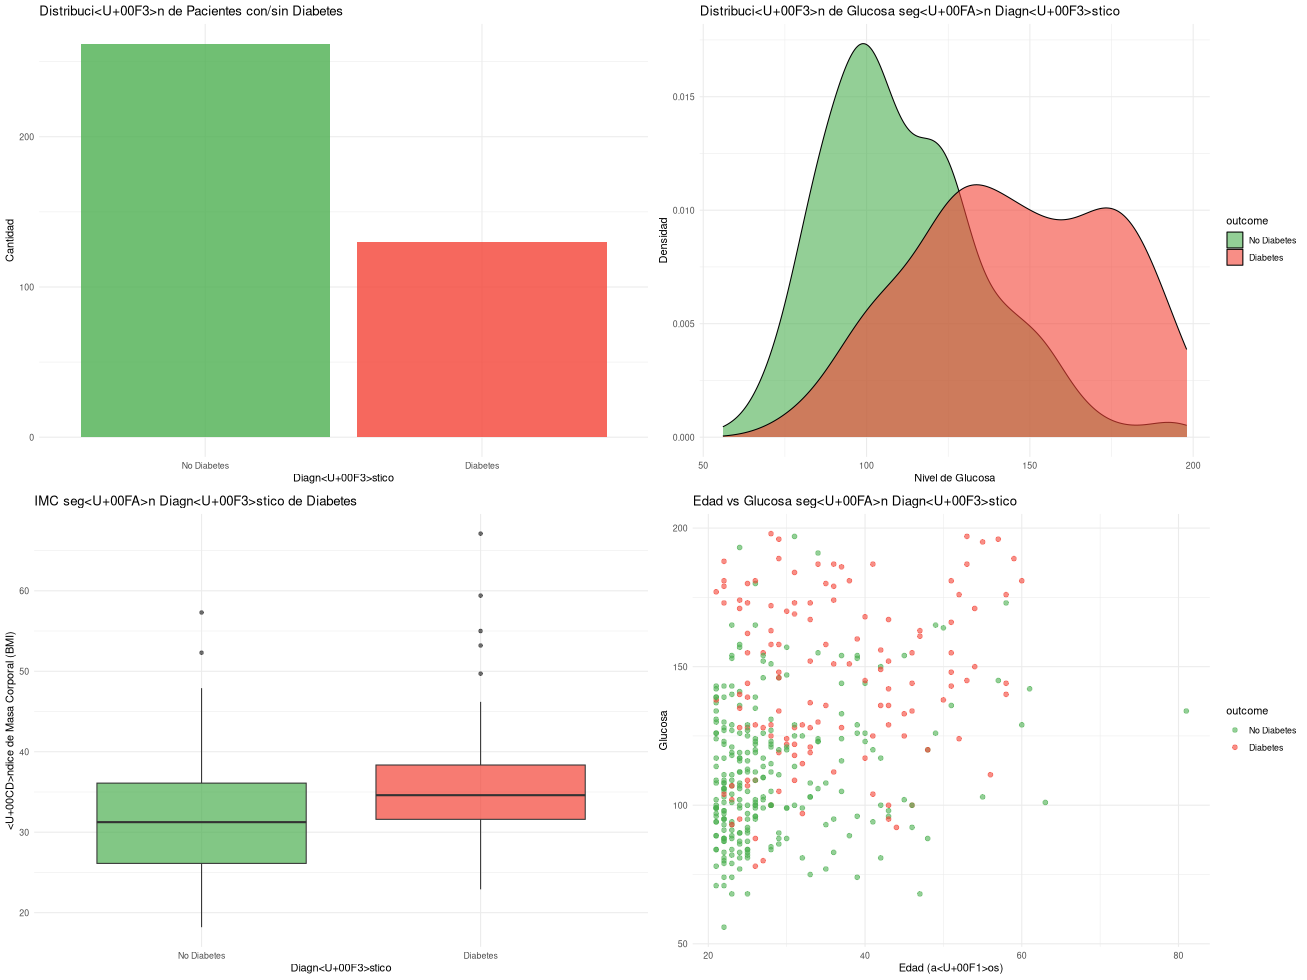


Tama<U+00F1>o train: 275 
Tama<U+00F1>o test: 117 

=== MODELO FINAL ===

=== TEST DE HOSMER-LEMESHOW ===

	Hosmer and Lemeshow goodness of fit (GOF) test

data:  modelo_diabetes$y, fitted(modelo_diabetes)
X-squared = 8.4328, df = 8, p-value = 0.3924

p-valor: 0.3923765 
Interpretaci<U+00F3>n: p > 0.05 indica buen ajuste del modelo
Confusion Matrix and Statistics

             Reference
Prediction    No Diabetes Diabetes
  No Diabetes          70       19
  Diabetes              8       20
                                          
               Accuracy : 0.7692          
                 95% CI : (0.6823, 0.8421)
    No Information Rate : 0.6667          
    P-Value [Acc > NIR] : 0.01041         
                                          
                  Kappa : 0.4414          
                                          
 Mcnemar's Test P-Value : 0.05429         
                                          
            Sensitivity : 0.5128          
            Specificity : 0.897

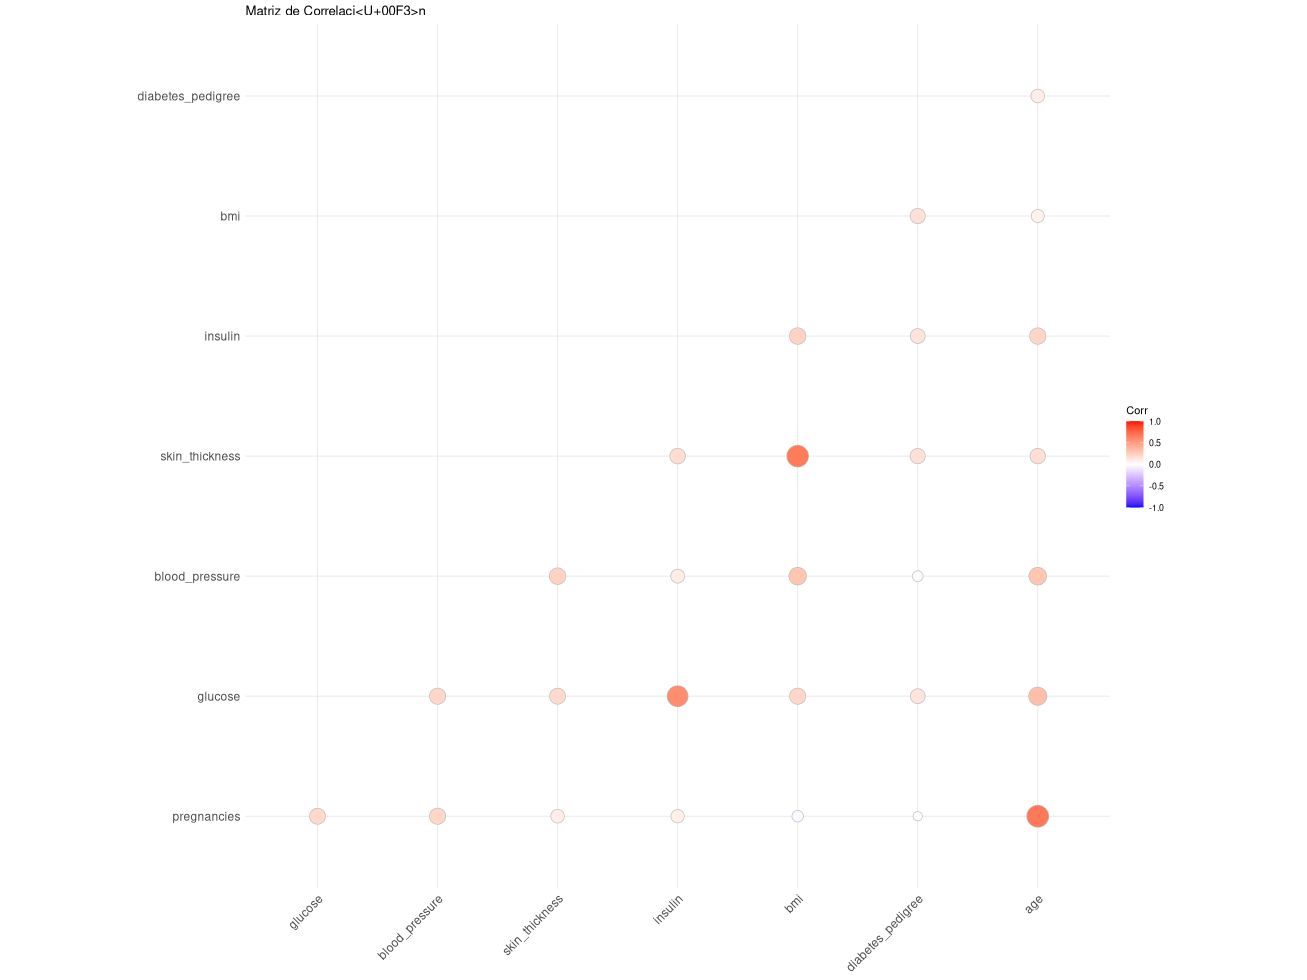


=== ODDS RATIOS ===
Waiting for profiling to be done...
                           Variable    OR IC_2.5 IC_97.5
(Intercept)             (Intercept) 0.000  0.000   0.000
glucose                     glucose 1.041  1.029   1.054
bmi                             bmi 1.090  1.038   1.149
diabetes_pedigree diabetes_pedigree 4.398  1.580  12.942
age                             age 1.044  1.013   1.077


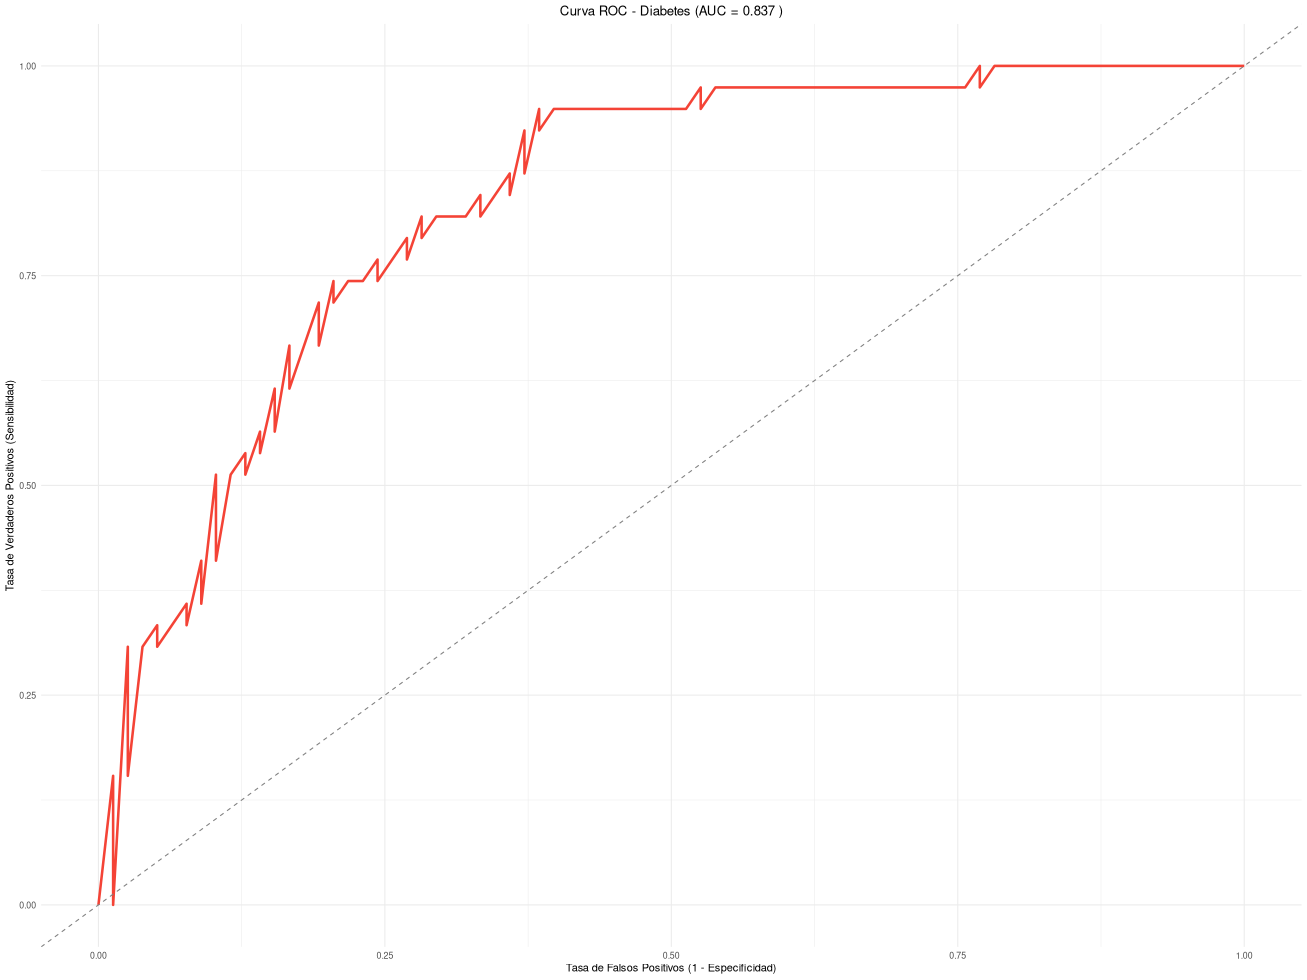

In [5]:
# ============================================
# EJEMPLO 1: PREDICCIÓN DE DIABETES TIPO 2
# Dataset: Pima Indians Diabetes (UCI)
# ============================================

# Cargar librerías
library(ggplot2)
library(dplyr)
library(caret)
library(pROC)
library(gridExtra)
library(ResourceSelection)

# ============================================
# 1. CARGA DE DATOS
# ============================================
url_diabetes <- "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df_diabetes <- read.csv(url_diabetes, header = FALSE)

# Asignar nombres a las columnas
colnames(df_diabetes) <- c("pregnancies", "glucose", "blood_pressure", 
                           "skin_thickness", "insulin", "bmi", 
                           "diabetes_pedigree", "age", "outcome")

# ============================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================
cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df_diabetes)
cat("\nDimensiones:", nrow(df_diabetes), "filas x", ncol(df_diabetes), "columnas\n")

# Detectar valores cero (en este dataset los 0 en ciertas variables son missing)
cat("\n=== VALORES CERO (potenciales missing) ===\n")
sapply(df_diabetes[, -9], function(x) sum(x == 0))

# Reemplazar ceros por NA en variables donde 0 no tiene sentido biológico
vars_a_reemplazar <- c("glucose", "blood_pressure", "skin_thickness", 
                       "insulin", "bmi")
df_diabetes[vars_a_reemplazar] <- lapply(df_diabetes[vars_a_reemplazar], 
                                          function(x) { x[x == 0] <- NA; x })

cat("\nValores NA después de reemplazo:\n")
sapply(df_diabetes, function(x) sum(is.na(x)))

# Eliminar filas con NA para simplificar el modelo
df_diabetes_clean <- na.omit(df_diabetes)
cat("\nFilas después de eliminar NA:", nrow(df_diabetes_clean), "\n")

# Convertir variable objetivo a factor
df_diabetes_clean$outcome <- factor(df_diabetes_clean$outcome, 
                                     levels = c(0, 1), 
                                     labels = c("No Diabetes", "Diabetes"))

# Distribución de la variable objetivo
cat("\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===\n")
print(table(df_diabetes_clean$outcome))
print(prop.table(table(df_diabetes_clean$outcome)) * 100)

# Gráfico 1: Distribución de la variable objetivo
p1 <- ggplot(df_diabetes_clean, aes(x = outcome, fill = outcome)) +
  geom_bar(alpha = 0.8) +
  scale_fill_manual(values = c("#4CAF50", "#F44336")) +
  labs(title = "Distribución de Pacientes con/sin Diabetes",
       x = "Diagnóstico", y = "Cantidad") +
  theme_minimal() + theme(legend.position = "none")

# Gráfico 2: Distribución de glucosa por diagnóstico
p2 <- ggplot(df_diabetes_clean, aes(x = glucose, fill = outcome)) +
  geom_density(alpha = 0.6) +
  scale_fill_manual(values = c("#4CAF50", "#F44336")) +
  labs(title = "Distribución de Glucosa según Diagnóstico",
       x = "Nivel de Glucosa", y = "Densidad") +
  theme_minimal()

# Gráfico 3: Boxplot de BMI por diagnóstico
p3 <- ggplot(df_diabetes_clean, aes(x = outcome, y = bmi, fill = outcome)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("#4CAF50", "#F44336")) +
  labs(title = "IMC según Diagnóstico de Diabetes",
       x = "Diagnóstico", y = "Índice de Masa Corporal (BMI)") +
  theme_minimal() + theme(legend.position = "none")

# Gráfico 4: Relación edad vs glucosa
p4 <- ggplot(df_diabetes_clean, aes(x = age, y = glucose, color = outcome)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_color_manual(values = c("#4CAF50", "#F44336")) +
  labs(title = "Edad vs Glucosa según Diagnóstico",
       x = "Edad (años)", y = "Glucosa") +
  theme_minimal()

grid.arrange(p1, p2, p3, p4, ncol = 2)

# Matriz de correlación
cor_matrix <- cor(df_diabetes_clean[, -9])
corr_plot <- ggcorrplot::ggcorrplot(cor_matrix, method = "circle", 
                                     type = "lower", 
                                     title = "Matriz de Correlación")
print(corr_plot)

# ============================================
# 3. DIVISIÓN TRAIN / TEST
# ============================================
set.seed(123)
train_index <- createDataPartition(df_diabetes_clean$outcome, p = 0.7, 
                                    list = FALSE)
train_data <- df_diabetes_clean[train_index, ]
test_data  <- df_diabetes_clean[-train_index, ]

cat("\nTamaño train:", nrow(train_data), "\n")
cat("Tamaño test:", nrow(test_data), "\n")

# ============================================
# 4. MODELO DE REGRESIÓN LOGÍSTICA
# ============================================
# Modelo completo inicial
modelo_diabetes_full <- glm(outcome ~ ., data = train_data, family = binomial)
summary(modelo_diabetes_full)

# Selección de variables por stepwise (AIC)
modelo_diabetes <- step(modelo_diabetes_full, direction = "both", trace = 0)
cat("\n=== MODELO FINAL ===\n")
summary(modelo_diabetes)

# Test de Hosmer-Lemeshow (bondad de ajuste)
hl_test <- hoslem.test(modelo_diabetes$y, fitted(modelo_diabetes), g = 10)
cat("\n=== TEST DE HOSMER-LEMESHOW ===\n")
print(hl_test)
cat("p-valor:", hl_test$p.value, "\n")
cat("Interpretación: p > 0.05 indica buen ajuste del modelo\n")

# ============================================
# 5. EVALUACIÓN DEL MODELO
# ============================================
# Predicciones en test
prob_test <- predict(modelo_diabetes, newdata = test_data, type = "response")
pred_class <- ifelse(prob_test > 0.5, "Diabetes", "No Diabetes")
pred_class <- factor(pred_class, levels = c("No Diabetes", "Diabetes"))

# Matriz de confusión
conf_matrix <- confusionMatrix(pred_class, test_data$outcome, positive = "Diabetes")
print(conf_matrix)

# Curva ROC
roc_obj <- roc(test_data$outcome, prob_test, 
               levels = c("No Diabetes", "Diabetes"))
cat("\n=== ÁREA BAJO LA CURVA (AUC) ===\n")
print(auc(roc_obj))

# Gráfico de curva ROC
ggplot(data.frame(
  FPR = 1 - roc_obj$specificities,
  TPR = roc_obj$sensitivities
), aes(x = FPR, y = TPR)) +
  geom_line(color = "#F44336", size = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = paste("Curva ROC - Diabetes (AUC =", 
                     round(auc(roc_obj), 3), ")"),
       x = "Tasa de Falsos Positivos (1 - Especificidad)",
       y = "Tasa de Verdaderos Positivos (Sensibilidad)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

# Odds Ratios
cat("\n=== ODDS RATIOS ===\n")
OR <- exp(coef(modelo_diabetes))
OR_CI <- exp(confint(modelo_diabetes))
or_df <- data.frame(
  Variable = names(OR),
  OR = round(OR, 3),
  IC_2.5 = round(OR_CI[, 1], 3),
  IC_97.5 = round(OR_CI[, 2], 3)
)
print(or_df)

### Ejemplo 2: Predicción de Enfermedad Cardíaca (Heart Disease Cleveland)
Dataset del Cleveland Clinic Foundation, disponible en UCI Machine Learning Repository.

ResourceSelection 0.3-6 	 2023-06-27
=== ESTRUCTURA DEL DATASET ===
'data.frame':	303 obs. of  14 variables:
 $ age     : num  63 67 67 37 41 56 62 57 63 53 ...
 $ sex     : num  1 1 1 1 0 1 0 0 1 1 ...
 $ cp      : num  1 4 4 3 2 2 4 4 4 4 ...
 $ trestbps: num  145 160 120 130 130 120 140 120 130 140 ...
 $ chol    : num  233 286 229 250 204 236 268 354 254 203 ...
 $ fbs     : num  1 0 0 0 0 0 0 0 0 1 ...
 $ restecg : num  2 2 2 0 2 0 2 0 2 2 ...
 $ thalach : num  150 108 129 187 172 178 160 163 147 155 ...
 $ exang   : num  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 1.4 3.1 ...
 $ slope   : num  3 2 2 3 1 1 3 1 2 3 ...
 $ ca      : num  0 3 2 0 0 0 2 0 1 0 ...
 $ thal    : num  6 3 7 3 3 3 3 3 7 7 ...
 $ target  : int  0 2 1 0 0 0 3 0 2 1 ...

Valores NA por columna:
     age      sex       cp trestbps     chol      fbs  restecg  thalach 
       0        0        0        0        0        0        0        0 
   exang  oldpeak    slope       ca     th

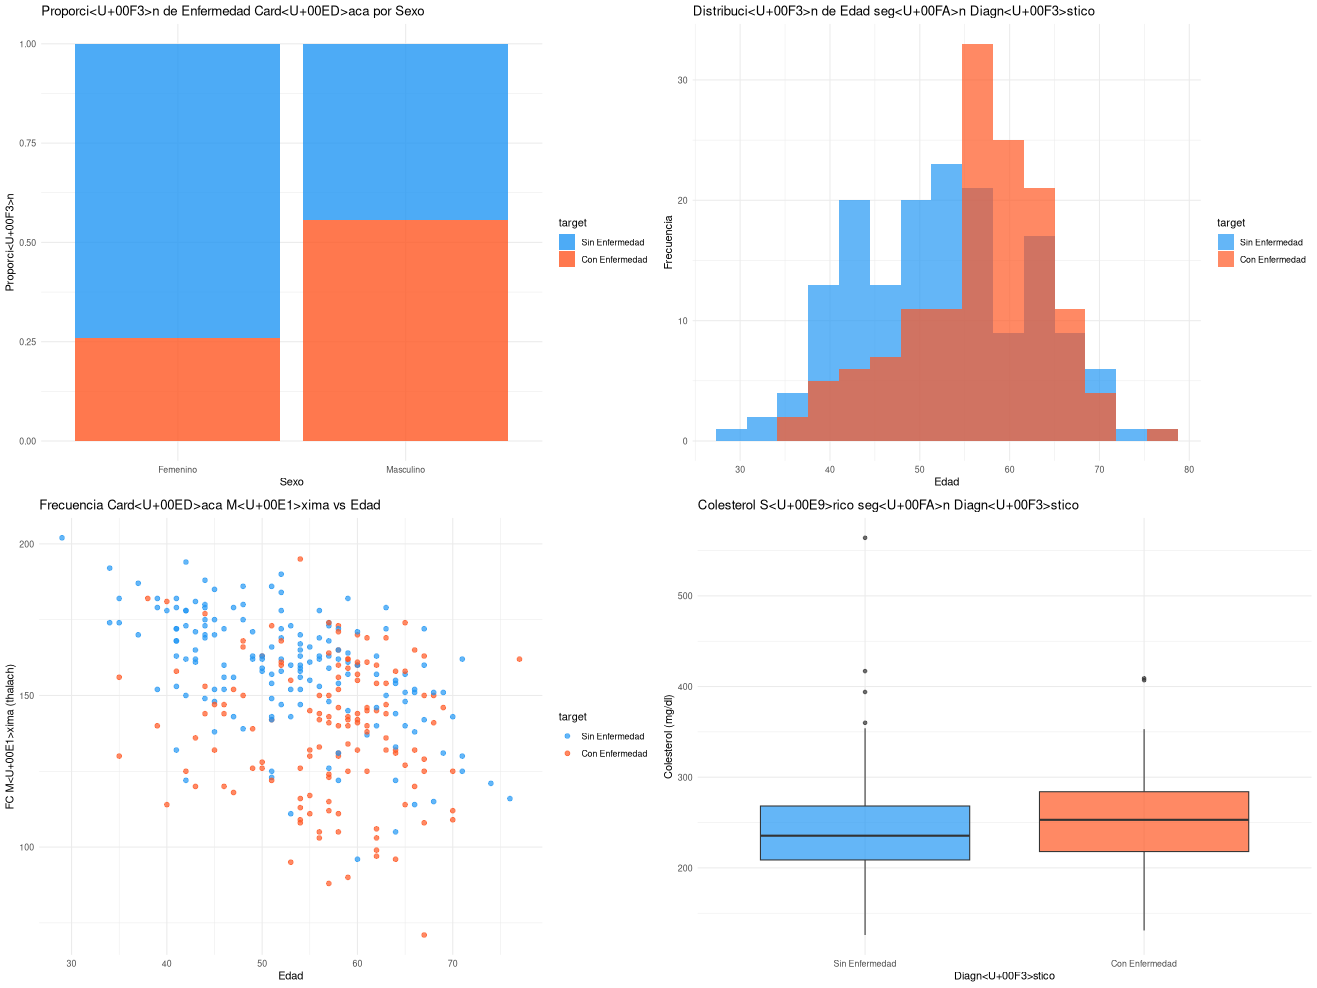

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 



=== ODDS RATIOS ===
Waiting for profiling to be done...
                 Variable     OR IC_2.5 IC_97.5
(Intercept)   (Intercept)  0.000  0.000   0.002
sexMasculino sexMasculino  5.605  1.587  22.304
cp2                   cp2  5.533  0.839  39.649
cp3                   cp3  1.637  0.337   8.472
cp4                   cp4 35.481  7.399 213.571
trestbps         trestbps  1.021  0.994   1.049
chol                 chol  1.009  0.998   1.020
oldpeak           oldpeak  1.938  1.136   3.570
slope2             slope2  6.370  2.109  21.488
slope3             slope3  0.718  0.060   7.330
ca1                   ca1 11.193  3.553  39.808
ca2                   ca2 18.944  3.538 124.673
ca3                   ca3  3.230  0.600  25.527
thal6               thal6  0.216  0.025   1.685
thal7               thal7  3.700  1.251  11.499


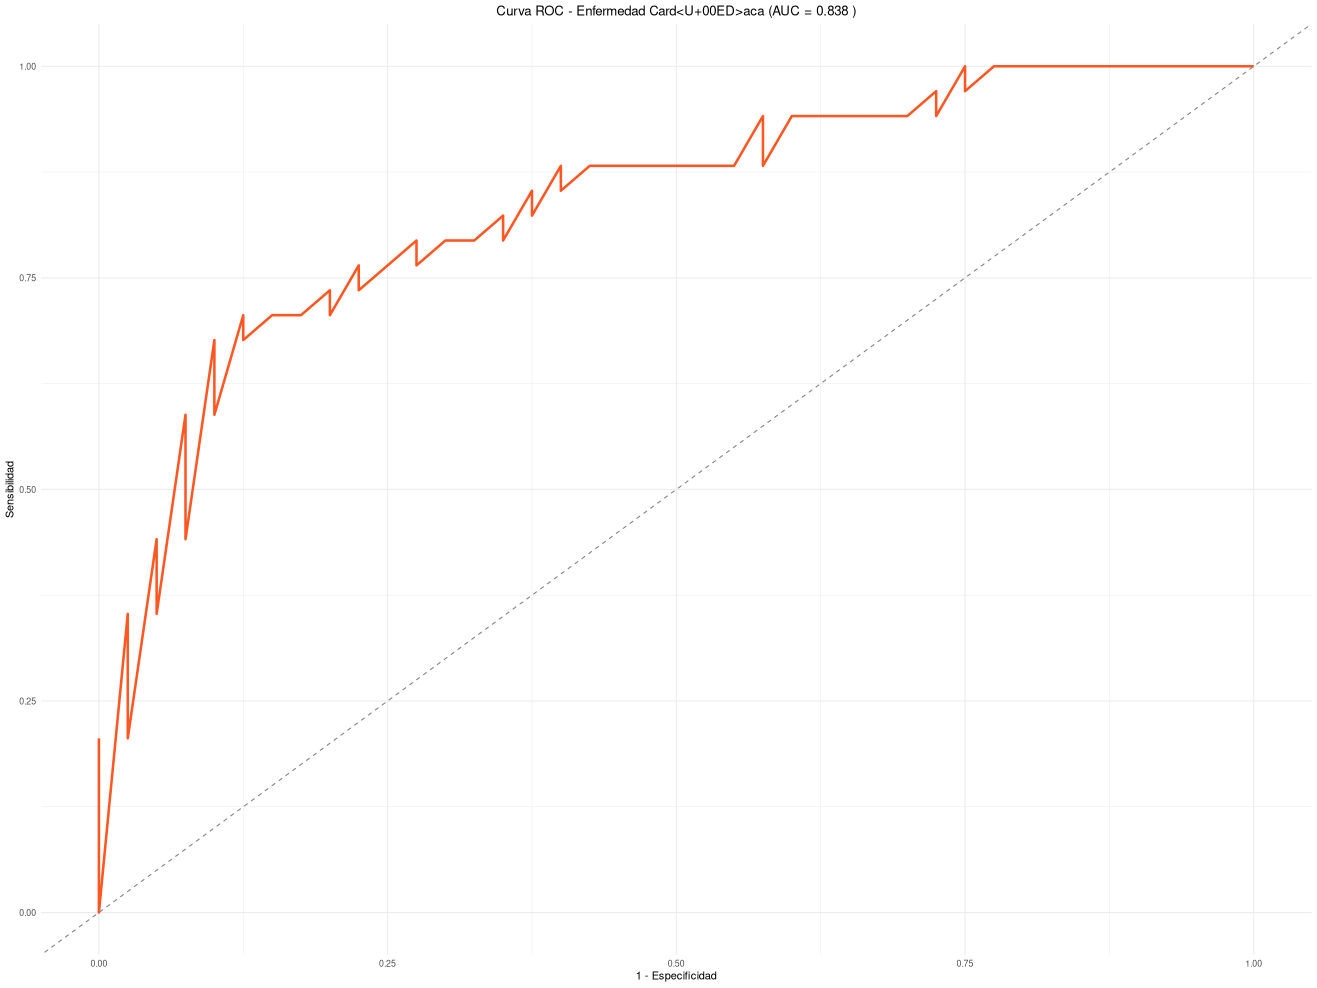

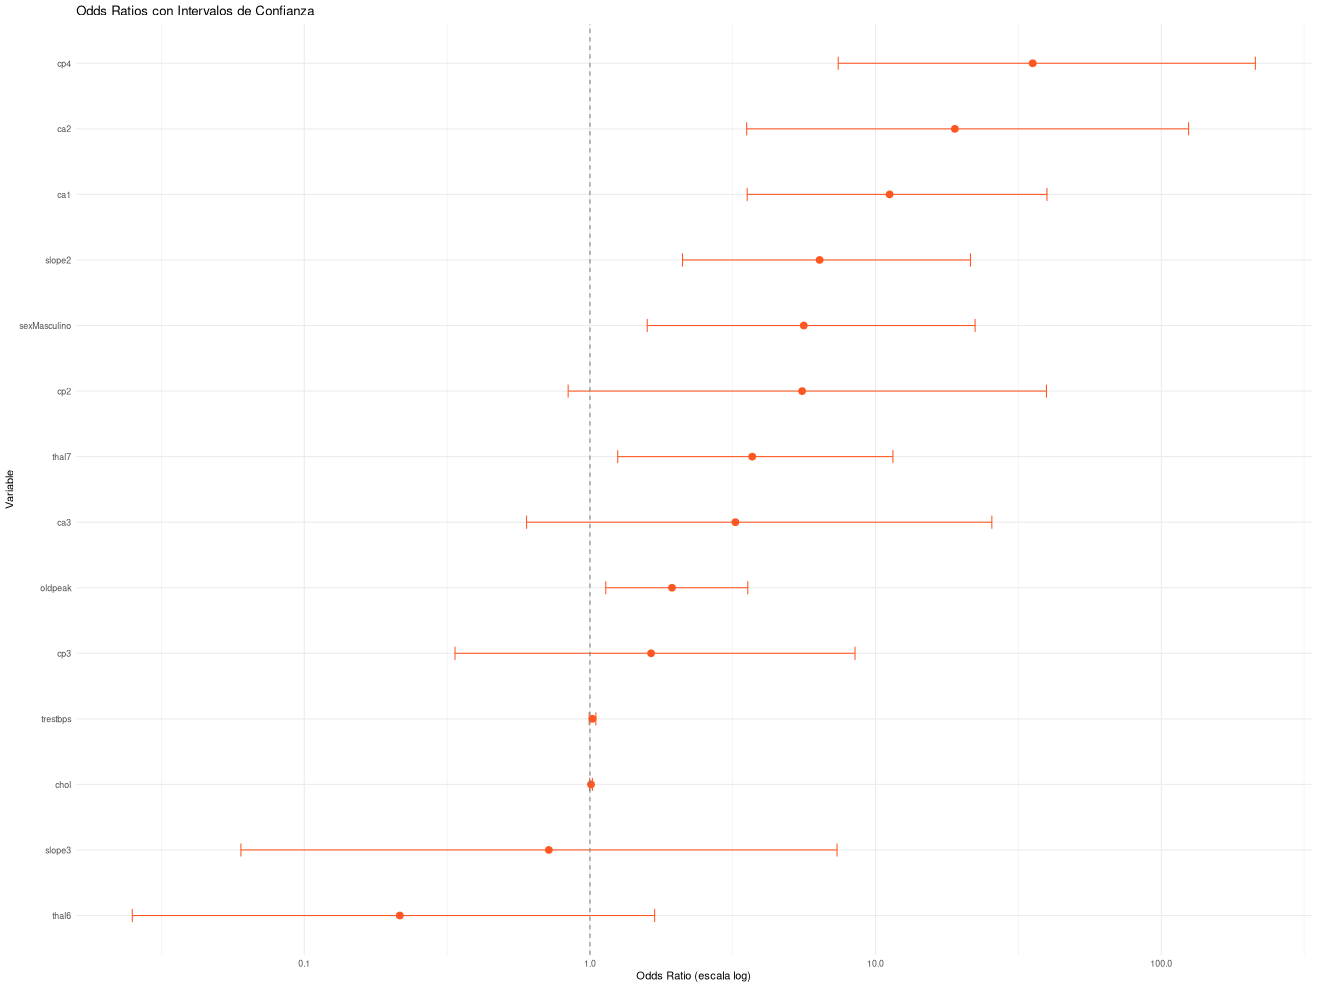

In [2]:
# ============================================
# EJEMPLO 2: PREDICCIÓN DE ENFERMEDAD CARDÍACA
# Dataset: Heart Disease - Cleveland (UCI)
# ============================================

library(ggplot2)
library(dplyr)
library(caret)
library(pROC)
library(gridExtra)
library(ResourceSelection)

# ============================================
# 1. CARGA DE DATOS
# ============================================
url_heart <- "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df_heart <- read.csv(url_heart, header = FALSE, na.strings = "?")

colnames(df_heart) <- c("age", "sex", "cp", "trestbps", "chol", "fbs", 
                        "restecg", "thalach", "exang", "oldpeak", "slope", 
                        "ca", "thal", "target")

cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df_heart)
cat("\nValores NA por columna:\n")
print(colSums(is.na(df_heart)))

# Eliminar filas con NA
df_heart_clean <- na.omit(df_heart)
cat("\nFilas después de limpiar:", nrow(df_heart_clean), "\n")

# La variable target tiene valores 0-4 (grados de enfermedad)
# La binarizamos: 0 = sin enfermedad, 1-4 = con enfermedad
df_heart_clean$target <- ifelse(df_heart_clean$target > 0, 1, 0)
df_heart_clean$target <- factor(df_heart_clean$target, 
                                 levels = c(0, 1),
                                 labels = c("Sin Enfermedad", "Con Enfermedad"))

# Convertir variables categóricas
df_heart_clean$sex <- factor(df_heart_clean$sex, labels = c("Femenino", "Masculino"))
df_heart_clean$cp <- factor(df_heart_clean$cp)       # tipo de dolor torácico
df_heart_clean$fbs <- factor(df_heart_clean$fbs)     # azúcar en ayunas > 120
df_heart_clean$restecg <- factor(df_heart_clean$restecg)
df_heart_clean$exang <- factor(df_heart_clean$exang) # angina por ejercicio
df_heart_clean$slope <- factor(df_heart_clean$slope)
df_heart_clean$ca <- factor(df_heart_clean$ca)       # vasos coloreados
df_heart_clean$thal <- factor(df_heart_clean$thal)   # talasemia

# ============================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================
cat("\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===\n")
print(table(df_heart_clean$target))
print(prop.table(table(df_heart_clean$target)) * 100)

# Gráfico 1: Distribución por sexo y enfermedad
p1 <- ggplot(df_heart_clean, aes(x = sex, fill = target)) +
  geom_bar(position = "fill", alpha = 0.8) +
  scale_fill_manual(values = c("#2196F3", "#FF5722")) +
  labs(title = "Proporción de Enfermedad Cardíaca por Sexo",
       x = "Sexo", y = "Proporción") +
  theme_minimal()

# Gráfico 2: Distribución de edad por diagnóstico
p2 <- ggplot(df_heart_clean, aes(x = age, fill = target)) +
  geom_histogram(bins = 15, alpha = 0.7, position = "identity") +
  scale_fill_manual(values = c("#2196F3", "#FF5722")) +
  labs(title = "Distribución de Edad según Diagnóstico",
       x = "Edad", y = "Frecuencia") +
  theme_minimal()

# Gráfico 3: Frecuencia cardíaca máxima vs edad
p3 <- ggplot(df_heart_clean, aes(x = age, y = thalach, color = target)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_manual(values = c("#2196F3", "#FF5722")) +
  labs(title = "Frecuencia Cardíaca Máxima vs Edad",
       x = "Edad", y = "FC Máxima (thalach)") +
  theme_minimal()

# Gráfico 4: Colesterol por diagnóstico
p4 <- ggplot(df_heart_clean, aes(x = target, y = chol, fill = target)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("#2196F3", "#FF5722")) +
  labs(title = "Colesterol Sérico según Diagnóstico",
       x = "Diagnóstico", y = "Colesterol (mg/dl)") +
  theme_minimal() + theme(legend.position = "none")

grid.arrange(p1, p2, p3, p4, ncol = 2)

# Tabla de contingencia: sexo vs enfermedad
cat("\n=== TABLA DE CONTINGENCIA: SEXO vs ENFERMEDAD ===\n")
tabla_sexo <- table(df_heart_clean$sex, df_heart_clean$target)
print(tabla_sexo)

# ============================================
# 3. DIVISIÓN TRAIN / TEST
# ============================================
set.seed(456)
train_idx <- createDataPartition(df_heart_clean$target, p = 0.75, list = FALSE)
train_heart <- df_heart_clean[train_idx, ]
test_heart  <- df_heart_clean[-train_idx, ]

cat("\nTamaño train:", nrow(train_heart), "\n")
cat("Tamaño test:", nrow(test_heart), "\n")

# ============================================
# 4. MODELO DE REGRESIÓN LOGÍSTICA
# ============================================
modelo_heart_full <- glm(target ~ ., data = train_heart, family = binomial)
summary(modelo_heart_full)

# Selección stepwise
modelo_heart <- step(modelo_heart_full, direction = "both", trace = 0)
cat("\n=== MODELO FINAL ===\n")
summary(modelo_heart)

# Hosmer-Lemeshow
hl_heart <- hoslem.test(modelo_heart$y, fitted(modelo_heart), g = 10)
cat("\n=== TEST DE HOSMER-LEMESHOW ===\n")
cat("Chi-cuadrado:", hl_heart$chi.squared, "\n")
cat("p-valor:", hl_heart$p.value, "\n")

# ============================================
# 5. EVALUACIÓN DEL MODELO
# ============================================
prob_heart <- predict(modelo_heart, newdata = test_heart, type = "response")
pred_heart <- ifelse(prob_heart > 0.5, "Con Enfermedad", "Sin Enfermedad")
pred_heart <- factor(pred_heart, levels = c("Sin Enfermedad", "Con Enfermedad"))

# Matriz de confusión
conf_heart <- confusionMatrix(pred_heart, test_heart$target, 
                               positive = "Con Enfermedad")
print(conf_heart)

# Curva ROC
roc_heart <- roc(test_heart$target, prob_heart, 
                 levels = c("Sin Enfermedad", "Con Enfermedad"))
cat("\nAUC:", auc(roc_heart), "\n")

# Gráfico ROC
ggplot(data.frame(
  FPR = 1 - roc_heart$specificities,
  TPR = roc_heart$sensitivities
), aes(x = FPR, y = TPR)) +
  geom_line(color = "#FF5722", size = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = paste("Curva ROC - Enfermedad Cardíaca (AUC =", 
                     round(auc(roc_heart), 3), ")"),
       x = "1 - Especificidad", y = "Sensibilidad") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

# Odds Ratios
cat("\n=== ODDS RATIOS ===\n")
OR_heart <- exp(coef(modelo_heart))
OR_CI_heart <- exp(confint(modelo_heart))
or_heart_df <- data.frame(
  Variable = names(OR_heart),
  OR = round(OR_heart, 3),
  IC_2.5 = round(OR_CI_heart[, 1], 3),
  IC_97.5 = round(OR_CI_heart[, 2], 3)
)
print(or_heart_df)

# Visualización de Odds Ratios
or_heart_df_clean <- or_heart_df[-1, ]  # quitar intercepto
ggplot(or_heart_df_clean, aes(x = reorder(Variable, OR), y = OR)) +
  geom_point(size = 3, color = "#FF5722") +
  geom_errorbar(aes(ymin = IC_2.5, ymax = IC_97.5), width = 0.2, color = "#FF5722") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(title = "Odds Ratios con Intervalos de Confianza",
       x = "Variable", y = "Odds Ratio (escala log)") +
  scale_y_log10() +
  theme_minimal()

### Ejemplo 3: Predicción de Bajo Peso al Nacer (Low Birth Weight)
Dataset clásico de Hosmer, Lemeshow y Sturdivant, disponible en el paquete MASS de R y en múltiples repositorios de salud pública.


Attaching package: 'MASS'

The following object is masked from 'package:dplyr':

    select

=== ESTRUCTURA DEL DATASET ===
'data.frame':	189 obs. of  10 variables:
 $ low  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ age  : int  19 33 20 21 18 21 22 17 29 26 ...
 $ lwt  : int  182 155 105 108 107 124 118 103 123 113 ...
 $ race : int  2 3 1 1 1 3 1 3 1 1 ...
 $ smoke: int  0 0 1 1 1 0 0 0 1 1 ...
 $ ptl  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ht   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ ui   : int  1 0 0 1 1 0 0 0 0 0 ...
 $ ftv  : int  0 3 1 2 0 0 1 1 1 0 ...
 $ bwt  : int  2523 2551 2557 2594 2600 2622 2637 2637 2663 2665 ...

Dimensiones: 189 filas x 10 columnas

Valores NA: 0 

=== DISTRIBUCI<U+00D3>N DE LA VARIABLE OBJETIVO ===

Peso Normal   Bajo Peso 
        130          59 

Peso Normal   Bajo Peso 
   68.78307    31.21693 
`geom_smooth()` using formula = 'y ~ x'

=== TABLA: FUMADORA vs BAJO PESO ===
             
              Peso Normal Bajo Peso
  No Fumadora          86        29
  Fumadora 

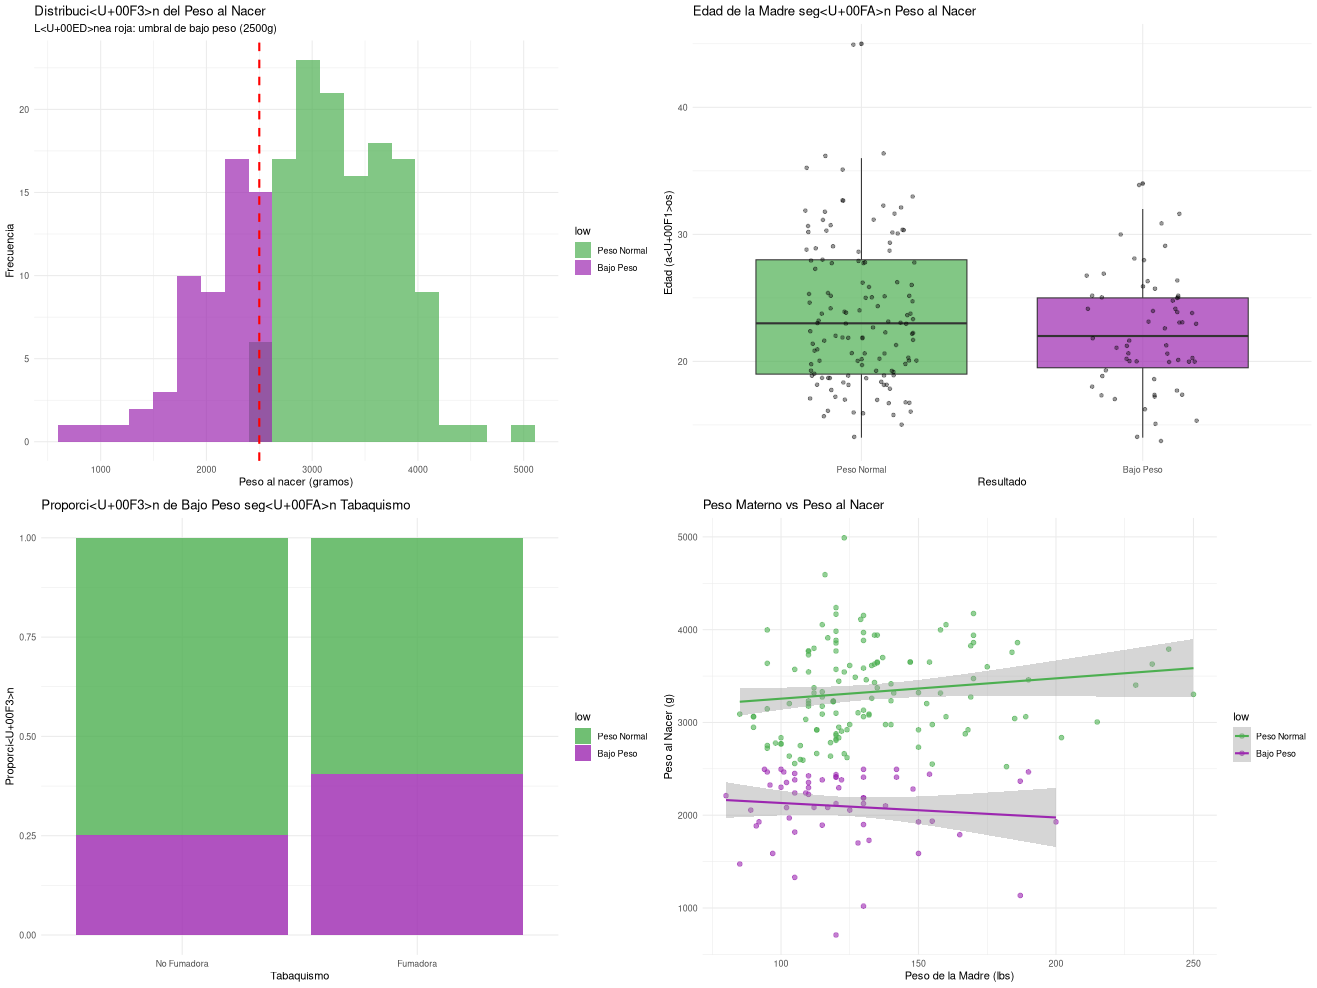


=== ODDS RATIOS ===
Waiting for profiling to be done...
               Variable     OR IC_2.5 IC_97.5
(Intercept) (Intercept)  6.838  0.607  91.517
age                 age  0.933  0.851   1.013
lwt                 lwt  0.987  0.970   1.001
ptl                 ptl 13.408  4.218  54.054
htCon HTA     htCon HTA 10.620  1.890  81.273


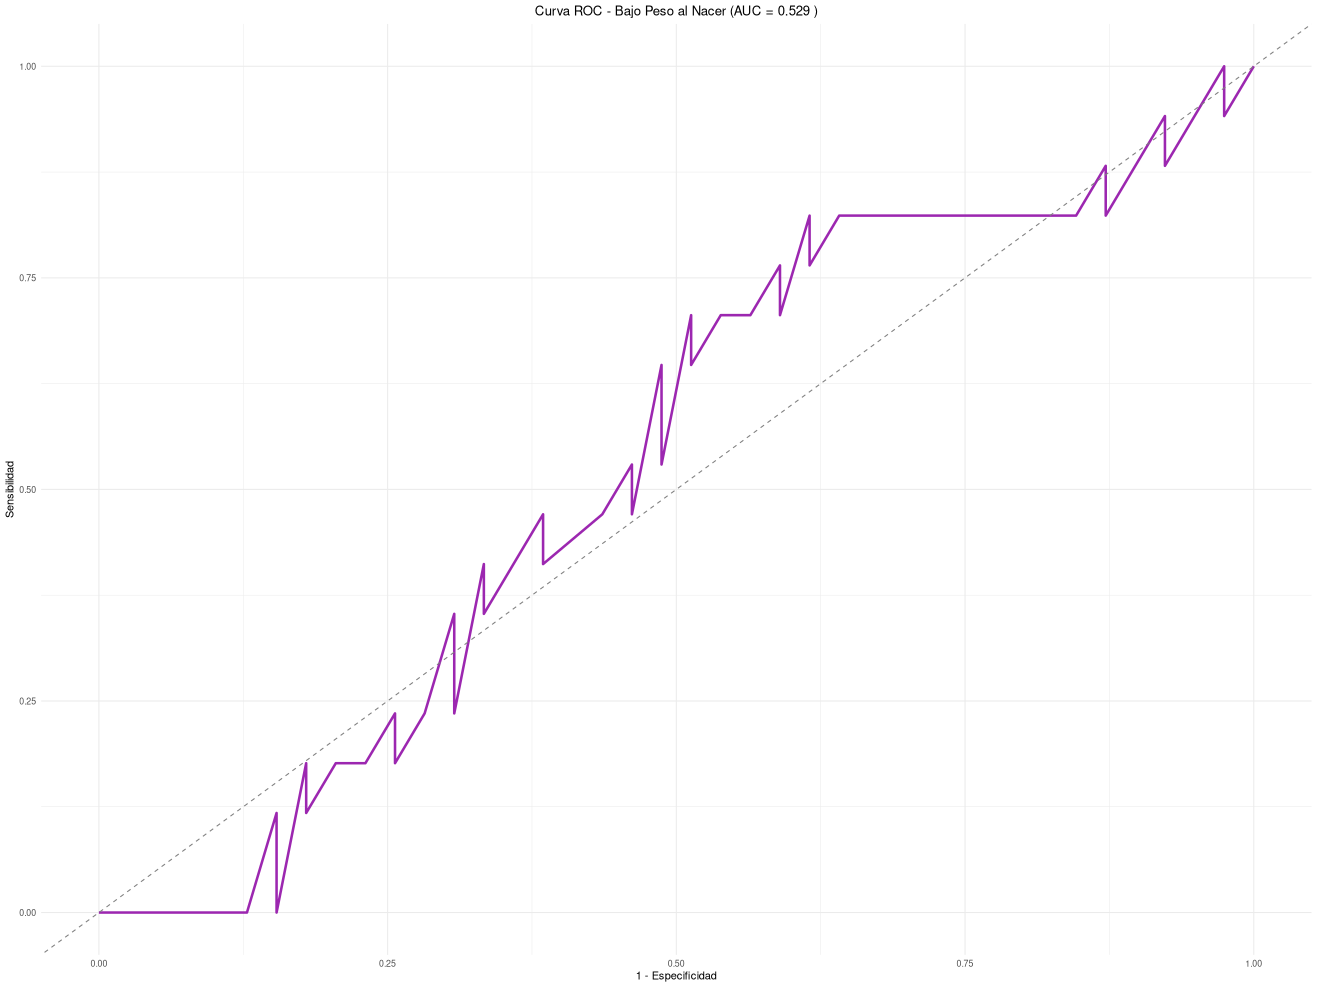

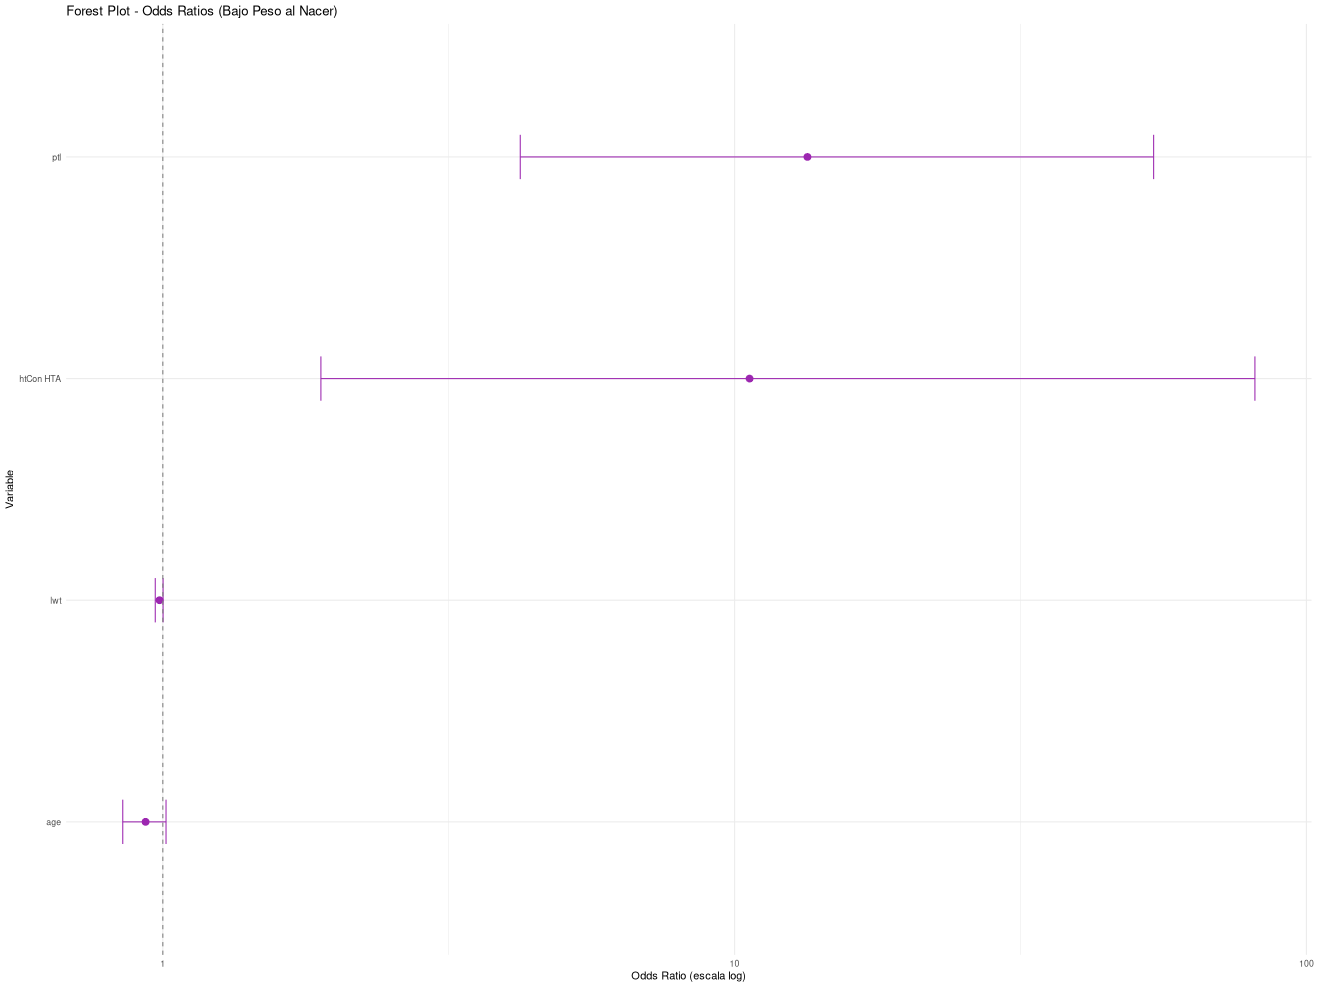

: [1m[33mError[39m in `[.data.frame`:[22m
[33m![39m undefined columns selected

In [3]:
# ============================================
# EJEMPLO 3: PREDICCIÓN DE BAJO PESO AL NACER
# Dataset: Low Birth Weight (Hosmer & Lemeshow)
# ============================================

library(ggplot2)
library(dplyr)
library(caret)
library(pROC)
library(gridExtra)
library(ResourceSelection)
library(MASS)

# ============================================
# 1. CARGA DE DATOS
# ============================================
# Opción 1: desde MASS (recomendado)
data(birthwt, package = "MASS")
df_birth <- birthwt

# Opción 2 (alternativa): descarga directa desde internet
# url_birth <- "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/birthwt.csv"
# df_birth <- read.csv(url_birth)

cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df_birth)
cat("\nDimensiones:", nrow(df_birth), "filas x", ncol(df_birth), "columnas\n")
cat("\nValores NA:", sum(is.na(df_birth)), "\n")

# Renombrar y recodificar variables para mayor claridad
df_birth <- df_birth %>%
  rename(
    low = low,                    # 1 = bajo peso, 0 = normal
    age = age,                    # edad de la madre
    lwt = lwt,                    # peso último de la madre
    race = race,                  # raza (1=blanca, 2=negra, 3=otra)
    smoke = smoke,                # fumadora durante embarazo
    ptl = ptl,                    # partos prematuros previos
    ht = ht,                      # historia de hipertensión
    ui = ui,                      # irritabilidad uterina
    ftv = ftv,                    # visitas prenatales
    bwt = bwt                     # peso al nacer en gramos (no usar como predictor)
  )

# Convertir a factores
df_birth$low   <- factor(df_birth$low, labels = c("Peso Normal", "Bajo Peso"))
df_birth$race  <- factor(df_birth$race, labels = c("Blanca", "Negra", "Otra"))
df_birth$smoke <- factor(df_birth$smoke, labels = c("No Fumadora", "Fumadora"))
df_birth$ht    <- factor(df_birth$ht, labels = c("Sin HTA", "Con HTA"))
df_birth$ui    <- factor(df_birth$ui, labels = c("Sin Irritabilidad", "Con Irritabilidad"))

# ============================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================
cat("\n=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===\n")
print(table(df_birth$low))
print(prop.table(table(df_birth$low)) * 100)

# Gráfico 1: Distribución del peso al nacer
p1 <- ggplot(df_birth, aes(x = bwt, fill = low)) +
  geom_histogram(bins = 20, alpha = 0.7, position = "identity") +
  geom_vline(xintercept = 2500, linetype = "dashed", color = "red", size = 1) +
  scale_fill_manual(values = c("#4CAF50", "#9C27B0")) +
  labs(title = "Distribución del Peso al Nacer",
       subtitle = "Línea roja: umbral de bajo peso (2500g)",
       x = "Peso al nacer (gramos)", y = "Frecuencia") +
  theme_minimal()

# Gráfico 2: Edad de la madre según resultado
p2 <- ggplot(df_birth, aes(x = low, y = age, fill = low)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.4, size = 1.5) +
  scale_fill_manual(values = c("#4CAF50", "#9C27B0")) +
  labs(title = "Edad de la Madre según Peso al Nacer",
       x = "Resultado", y = "Edad (años)") +
  theme_minimal() + theme(legend.position = "none")

# Gráfico 3: Tabaquismo y bajo peso
p3 <- ggplot(df_birth, aes(x = smoke, fill = low)) +
  geom_bar(position = "fill", alpha = 0.8) +
  scale_fill_manual(values = c("#4CAF50", "#9C27B0")) +
  labs(title = "Proporción de Bajo Peso según Tabaquismo",
       x = "Tabaquismo", y = "Proporción") +
  theme_minimal()

# Gráfico 4: Peso materno vs peso al nacer
p4 <- ggplot(df_birth, aes(x = lwt, y = bwt, color = low)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "lm", se = TRUE, size = 1) +
  scale_color_manual(values = c("#4CAF50", "#9C27B0")) +
  labs(title = "Peso Materno vs Peso al Nacer",
       x = "Peso de la Madre (lbs)", y = "Peso al Nacer (g)") +
  theme_minimal()

grid.arrange(p1, p2, p3, p4, ncol = 2)

# Tabla de contingencia: fumadora vs bajo peso
cat("\n=== TABLA: FUMADORA vs BAJO PESO ===\n")
print(table(df_birth$smoke, df_birth$low))

# Prueba de chi-cuadrado
chi_test <- chisq.test(df_birth$smoke, df_birth$low)
cat("\nPrueba Chi-cuadrado:\n")
print(chi_test)

# ============================================
# 3. DIVISIÓN TRAIN / TEST
# ============================================
set.seed(789)
train_idx <- createDataPartition(df_birth$low, p = 0.7, list = FALSE)
train_birth <- df_birth[train_idx, ]
test_birth  <- df_birth[-train_idx, ]

cat("\nTamaño train:", nrow(train_birth), "\n")
cat("Tamaño test:", nrow(test_birth), "\n")

# ============================================
# 4. MODELO DE REGRESIÓN LOGÍSTICA
# ============================================
# Modelo completo
modelo_birth_full <- glm(low ~ age + lwt + race + smoke + ptl + ht + ui + ftv,
                         data = train_birth, family = binomial)
summary(modelo_birth_full)

# Selección stepwise
modelo_birth <- step(modelo_birth_full, direction = "both", trace = 0)
cat("\n=== MODELO FINAL ===\n")
summary(modelo_birth)

# Hosmer-Lemeshow
hl_birth <- hoslem.test(modelo_birth$y, fitted(modelo_birth), g = 10)
cat("\n=== TEST DE HOSMER-LEMESHOW ===\n")
cat("p-valor:", hl_birth$p.value, "\n")

# ============================================
# 5. EVALUACIÓN DEL MODELO
# ============================================
prob_birth <- predict(modelo_birth, newdata = test_birth, type = "response")
pred_birth <- ifelse(prob_birth > 0.5, "Bajo Peso", "Peso Normal")
pred_birth <- factor(pred_birth, levels = c("Peso Normal", "Bajo Peso"))

# Matriz de confusión
conf_birth <- confusionMatrix(pred_birth, test_birth$low, 
                               positive = "Bajo Peso")
print(conf_birth)

# Curva ROC
roc_birth <- roc(test_birth$low, prob_birth, 
                 levels = c("Peso Normal", "Bajo Peso"))
cat("\nAUC:", auc(roc_birth), "\n")

# Gráfico ROC
ggplot(data.frame(
  FPR = 1 - roc_birth$specificities,
  TPR = roc_birth$sensitivities
), aes(x = FPR, y = TPR)) +
  geom_line(color = "#9C27B0", size = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = paste("Curva ROC - Bajo Peso al Nacer (AUC =", 
                     round(auc(roc_birth), 3), ")"),
       x = "1 - Especificidad", y = "Sensibilidad") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5))

# Odds Ratios
cat("\n=== ODDS RATIOS ===\n")
OR_birth <- exp(coef(modelo_birth))
OR_CI_birth <- exp(confint(modelo_birth))
or_birth_df <- data.frame(
  Variable = names(OR_birth),
  OR = round(OR_birth, 3),
  IC_2.5 = round(OR_CI_birth[, 1], 3),
  IC_97.5 = round(OR_CI_birth[, 2], 3)
)
print(or_birth_df)

# Forest plot de Odds Ratios
or_birth_plot <- or_birth_df[-1, ]  # sin intercepto
ggplot(or_birth_plot, aes(x = reorder(Variable, OR), y = OR)) +
  geom_point(size = 3, color = "#9C27B0") +
  geom_errorbar(aes(ymin = IC_2.5, ymax = IC_97.5), 
                width = 0.2, color = "#9C27B0") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray50") +
  coord_flip() +
  labs(title = "Forest Plot - Odds Ratios (Bajo Peso al Nacer)",
       x = "Variable", y = "Odds Ratio (escala log)") +
  scale_y_log10() +
  theme_minimal()

# Curva de predicción de probabilidad: peso materno vs probabilidad
# Manteniendo otras variables en su media/moda
new_data <- data.frame(
  lwt = seq(80, 250, by = 5),
  age = mean(train_birth$age, na.rm = TRUE),
  race = "Blanca",
  smoke = "No Fumadora",
  ptl = 0,
  ht = "Sin HTA",
  ui = "Sin Irritabilidad",
  ftv = median(train_birth$ftv, na.rm = TRUE)
)

# Solo incluir predictores del modelo final
vars_modelo <- names(coef(modelo_birth))[-1]
new_data <- new_data[, vars_modelo]

new_data$prob <- predict(modelo_birth, newdata = new_data, type = "response")

ggplot(new_data, aes(x = lwt, y = prob)) +
  geom_line(color = "#9C27B0", size = 1.2) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray50") +
  labs(title = "Probabilidad de Bajo Peso según Peso Materno",
       subtitle = "Manteniendo otras variables constantes",
       x = "Peso Materno (lbs)",
       y = "Probabilidad de Bajo Peso al Nacer") +
  theme_minimal() +
  ylim(0, 1)